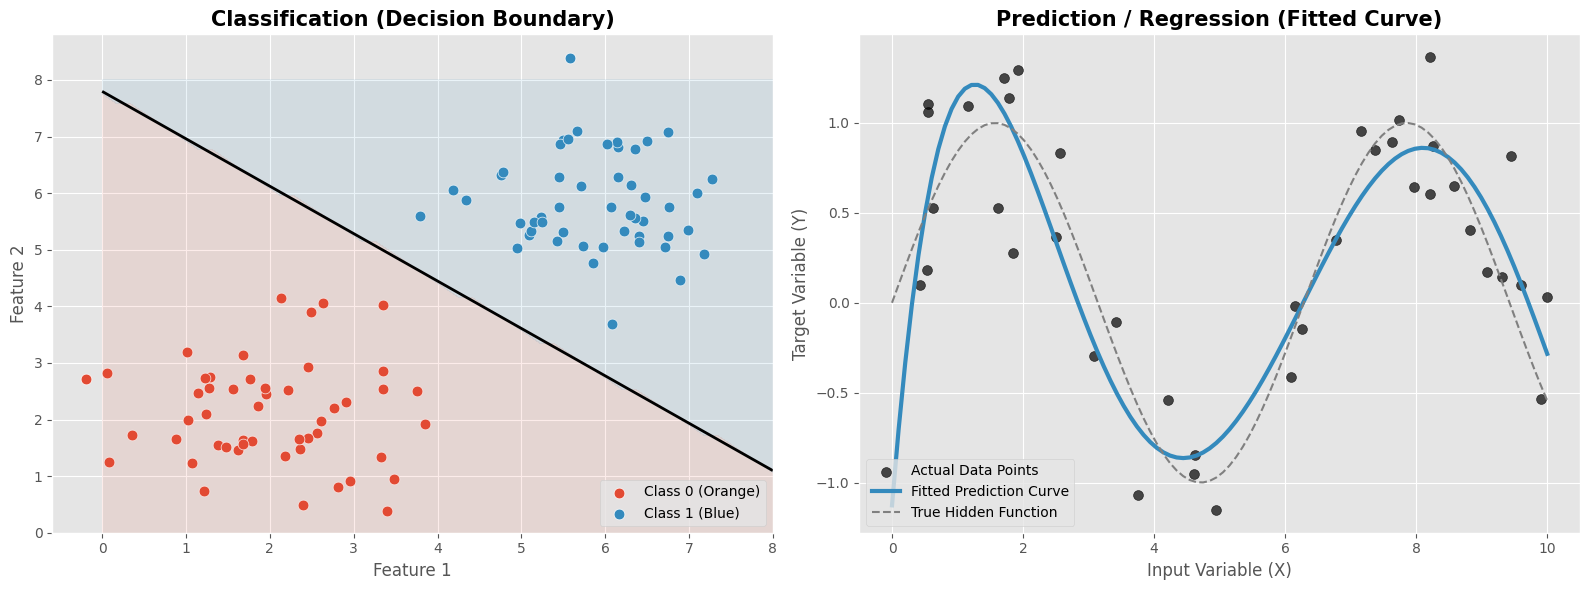

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Set the style
plt.style.use('ggplot')

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. CLASSIFICATION EXAMPLE
# (Separating two groups of points)
np.random.seed(13)

# Generate Mock Data for Classification
# Group 1 (Orange) - concentrated around lower left
X1 = np.random.normal([2, 2], 1.0, (50, 2))
y1 = np.zeros(50)

# Group 2 (Blue) - concentrated around upper right
X2 = np.random.normal([6, 6], 1.0, (50, 2))
y2 = np.ones(50)

# Combine the data
X_class = np.vstack((X1, X2))
y_class = np.hstack((y1, y2))

# Train a Support Vector Classifier (SVC) with a linear kernel to find the boundary
clf = SVC(kernel='linear')
clf.fit(X_class, y_class)

# Plot the points
axes[0].scatter(X1[:, 0], X1[:, 1], color='#E24A33', s=60, edgecolors='white', label='Class 0 (Orange)')
axes[0].scatter(X2[:, 0], X2[:, 1], color='#348ABD', s=60, edgecolors='white', label='Class 1 (Blue)')

# Create a grid to evaluate the classifier and plot the decision boundary
xx, yy = np.meshgrid(np.linspace(0, 8, 50), np.linspace(0, 8, 50))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw the decision boundary (where Z = 0)
axes[0].contour(xx, yy, Z, colors='black', levels=[0], linestyles=['-'], linewidths=2)

# Fill the background to show classification regions
axes[0].contourf(xx, yy, Z > 0, alpha=0.1, colors=['#E24A33', '#348ABD'])

axes[0].set_title('Classification (Decision Boundary)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].legend(loc='lower right')


# 2. PREDICTION / REGRESSION EXAMPLE
# (Fitting a curve to noisy data)
# Generate Mock Data for Prediction (a sine wave with noise)
X_pred = np.sort(np.random.uniform(0, 10, 40))
# The underlying true function is a sine wave, but we add random noise
y_pred = np.sin(X_pred) + np.random.normal(0, 0.3, 40)

# Reshape X for sklearn
X_pred_re = X_pred[:, np.newaxis]

# Train a Polynomial Regression model (Degree 5 allows the line to curve like a sine wave)
# We use a pipeline to combine feature transformation and linear regression
degree = 5
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_pred_re, y_pred)

# Generate points for the smooth prediction curve
X_smooth = np.linspace(0, 10, 100)[:, np.newaxis]
y_smooth = poly_model.predict(X_smooth)

# Plot the actual noisy data points
axes[1].scatter(X_pred, y_pred, color='black', s=50, alpha=0.7, label='Actual Data Points')

# Plot the fitted prediction curve
axes[1].plot(X_smooth, y_smooth, color='#348ABD', linewidth=3, label='Fitted Prediction Curve')

# Optional: Plot the True underlying function (without noise) to see how well it fits
axes[1].plot(X_smooth, np.sin(X_smooth), color='gray', linestyle='--', linewidth=1.5, label='True Hidden Function')

axes[1].set_title('Prediction / Regression (Fitted Curve)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Input Variable (X)', fontsize=12)
axes[1].set_ylabel('Target Variable (Y)', fontsize=12)
axes[1].legend(loc='lower left')

# Adjust layout and show
plt.tight_layout()
plt.show()